# Two-Dimensional Bond Percolation Model

In this tutorial, we analyze the 2D bond percolation problem using `jaxfss` and **Flax NNX** to simultaneously estimate three critical parameters: $(c_1, c_2, p_{\mathrm{c}})$.


## 1. Theoretical Background

In 2D bond percolation on a square lattice, the mean cluster size $\chi^{\mathrm{f}}(p, L)$ satisfies the finite-size scaling relation:

$$
\chi^{\mathrm{f}}(p, L) = L^{-c_2} F\left[ (p - p_{\mathrm{c}}) L^{c_1} \right]
$$

Exact values for 2D percolation:
* $p_{\mathrm{c}} = 1/2 = 0.5$
* $c_1 = 1/\nu = 3/4 = 0.75$
* $c_2 = -\gamma/\nu = -7/4 = -1.75$


## 2. Load and Inspect Data

We load data from `data/percolation.txt`.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
import optax
from softclip import SoftClip

import jaxfss

dataset = jaxfss.CriticalData.from_file("data/percolation.txt")
print(f"Loaded {dataset.n_data} data points.")
print(f"System sizes: {jnp.unique(dataset.Ls)}")

Loaded 150 data points.
System sizes: [ 64. 128. 256.]


Visualize the raw cluster susceptibility data.

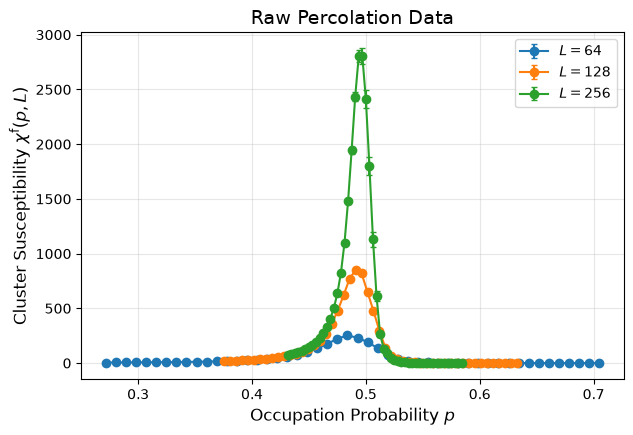

In [2]:
plt.figure(figsize=(7, 4.5))
unique_Ls = sorted(list(set(dataset.Ls.flatten().tolist())))
for L in unique_Ls:
    idx = dataset.Ls.flatten() == L
    plt.errorbar(
        dataset.Ts.flatten()[idx],
        dataset.As.flatten()[idx],
        yerr=dataset.As_err.flatten()[idx],
        fmt="o-",
        label=f"$L = {int(L)}$",
        capsize=2
    )

plt.xlabel(r"Occupation Probability $p$", fontsize=12)
plt.ylabel(r"Cluster Susceptibility $\chi^{\mathrm{f}}(p, L)$", fontsize=12)
plt.title("Raw Percolation Data", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Set Up NNX Scaling Model

For percolation, we estimate $(c_1, c_2, p_{\mathrm{c}})$ with constraints:
* $c_1 > 0$ via `SoftClip(low=0.0)`
* $c_2 < 0$ via `SoftClip(high=0.0)`
* Scaled $p_{\mathrm{c}} \in [-1, 1]$ via `SoftClip(low=-1.0, high=1.0)`

In [3]:
bij_c1 = SoftClip(low=0.0)
bij_c2 = SoftClip(high=0.0)
bij_pc = SoftClip(low=-1.0, high=1.0)

def bijector(p):
    p1, p2, pc = p
    return jnp.array([
        bij_c1.forward(p1),
        bij_c2.forward(p2),
        bij_pc.forward(pc)
    ])

scaling_fn = jaxfss.RationalMLP(din=1, features=[20, 20, 1], rngs=nnx.Rngs(42))
model = jaxfss.FSSModel(scaling_fn=scaling_fn, n_critical=3, bijector=bijector)

train_data = dataset.train_data
Ls = train_data["system_size"]
Ts = train_data["temperature"]
As = train_data["observable"]
vAs = train_data["observable_var"]

def loss_fn(m: jaxfss.FSSModel):
    y_pred = m(Ls, Ts)
    c2 = m.critical_params[1]
    y_true = m.scaled_target(Ls, As)
    V = vAs * (Ls ** (2 * c2))
    return jaxfss.NLLLoss(y_true, y_pred, V)

## 4. Optimization with NNX

In [4]:
optimizer = {
    "scaling_fn": optax.adam(learning_rate=1e-3),
    "fss": optax.adam(learning_rate=1e-2)
}
steps = 10000

losses, critical_vals = jaxfss.fit(model, loss_fn, optimizer, steps)

c1_est, c2_est, scaled_pc_est = model.critical_params
pc_est = float(dataset.bij_temperature.inverse(scaled_pc_est))
c1_est = float(c1_est)
c2_est = float(c2_est)

print("=== Estimation Results ===")
print(f"c_1 (exact = 0.75000)   : {c1_est:.5f}")
print(f"c_2 (exact = -1.75000)  : {c2_est:.5f}")
print(f"p_c (exact = 0.50000)   : {pc_est:.5f}")

=== Estimation Results ===
c_1 (exact = 0.75000)   : 0.75248
c_2 (exact = -1.75000)  : -1.76042
p_c (exact = 0.50000)   : 0.50026


## 5. Scaling Collapse and NN Fitting Curve

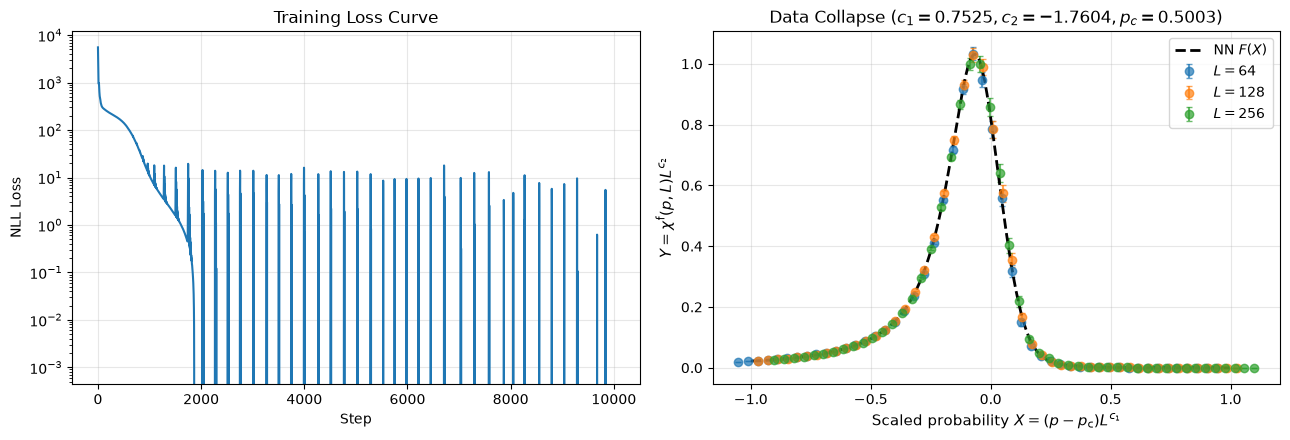

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Loss curve
ax1.plot(losses)
ax1.set_yscale("log")
ax1.set_xlabel("Step")
ax1.set_ylabel("NLL Loss")
ax1.set_title("Training Loss Curve")
ax1.grid(True, alpha=0.3)

# Scaling collapse
for L in unique_Ls:
    idx = dataset.Ls.flatten() == L
    t = Ts.flatten()[idx]
    s = Ls.flatten()[idx]
    x = (t - scaled_pc_est) * (s ** c1_est)
    y = As.flatten()[idx] * (s ** c2_est)
    yerr = jnp.sqrt(vAs.flatten()[idx]) * (s ** c2_est)
    ax2.errorbar(x, y, yerr=yerr, fmt="o", label=f"$L={int(L)}$", alpha=0.7, capsize=2)

# Plot NN prediction
x_grid = jnp.linspace(-1.0, 1.0, 200).reshape(-1, 1)
y_pred = model.scaling_fn(x_grid)
ax2.plot(x_grid, y_pred, color="black", lw=2, linestyle="--", label="NN $F(X)$")

ax2.set_xlabel(r"Scaled probability $X = (p - p_{\mathrm{c}}) L^{c_1}$", fontsize=11)
ax2.set_ylabel(r"$Y = \chi^{\mathrm{f}}(p, L) L^{c_2}$", fontsize=11)
ax2.set_title(f"Data Collapse ($c_1={c1_est:.4f}, c_2={c2_est:.4f}, p_c={pc_est:.4f}$)", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()